# Univariate Optimization and Line Search in Julia

This notebook introduces **bracketing methods**, **one-dimensional search**, and **line-search methods for local optimization**.

### Learning objectives
By the end of the notebook, you should be able to:
- define and visualize one-dimensional objective functions in Julia;
- bracket a local minimum or a sign change;
- apply Fibonacci, golden-section, quadratic-fit, and bisection searches;
- formulate an exact line search along a search direction;
- implement backtracking line search;
- interpret the role of line search in multivariate descent methods.

The notebook contains worked examples followed by **student exercises**. Exercise code cells are intentionally left blank.

## 0. Packages

In [1]:
using Plots
using LinearAlgebra
using LaTeXStrings
using Base.MathConstants
using Optim


If `Optim` is not installed, run the following once and then restart the kernel if necessary.

In [ ]:
# using Pkg
# Pkg.add("Optim")

## 1. A one-dimensional objective function

We begin with

$$f(x)=e^{x-2}-x$$


In Julia, a function may be defined either in one line or using the longer `function ... end` syntax.

In [2]:
f(x) = exp(x - 2) - x

function g_same(x)
    return exp(x - 2) - x
end

f(2), g_same(2)

(-1.0, -1.0)

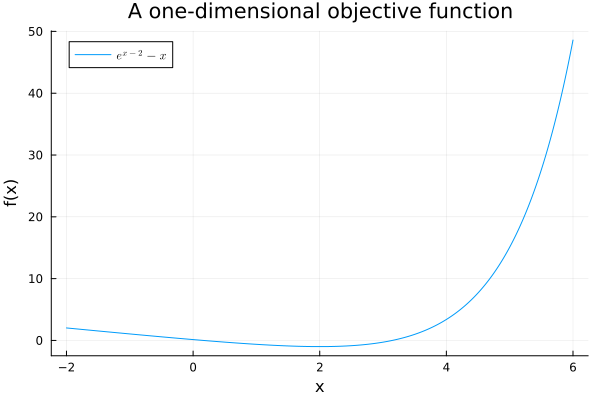

In [3]:
a, b = -2, 6
xgrid = a:0.01:b
ygrid = f.(xgrid)

plot(xgrid, ygrid,
    xlabel="x", ylabel="f(x)",
    label=L"e^{x-2}-x",
    title="A one-dimensional objective function")

### Exercise 1 — Exploring the objective
1. Evaluate `f` at `x = -2, 0, 2, 4, 6`.
2. From the plot, estimate the location of the minimum.
3. Plot the same function on the interval `[-1, 4]` and add a scatter point at your estimated minimizer.

In [ ]:
# Exercise 1
# Your code here


## 2. Bracketing a local minimum

Before applying many one-dimensional optimization methods, we first find an interval that contains a local minimum. The following routine expands a search interval until the middle sampled point has a lower objective value than the new point.

In [4]:
function bracket_minimum(f, x=0; s=1e-2, k=2.0)
    a, ya = x, f(x)
    b, yb = a + s, f(a + s)

    if yb > ya
        a, b = b, a
        ya, yb = yb, ya
        s = -s
    end

    while true
        c, yc = b + s, f(b + s)
        if yc > yb
            return a < c ? (a, c) : (c, a)
        end
        a, ya, b, yb = b, yb, c, yc
        s *= k
    end
end

bracket_minimum (generic function with 2 methods)

In [5]:
interval = bracket_minimum(f, 3; s=0.1, k=1.5)
println("Bracketed interval = ", interval)

Bracketed interval = (1.68125, 2.525)


### Exercise 2 — Effect of the bracketing parameters
Run `bracket_minimum` for the same function with different values of `x`, `s`, and `k`.

1. Try starting points `x = -1`, `1`, and `4`.
2. Compare `k = 1.2`, `1.5`, and `2.0`.
3. Explain what larger values of `k` do to the expansion of the interval.

In [6]:
# Exercise 2
# Your code here


## 3. Fibonacci search

Fibonacci search repeatedly shrinks a bracketing interval. It is useful when the number of function evaluations is fixed in advance.

In [7]:
function fibonacci_search(f, a, b, n; ϵ=1e-5)
    s = (1 - √5) / (1 + √5)
    ρ = 1 / (φ * (1 - s^(n + 1)) / (1 - s^n))
    r = (1 - ρ) * a + ρ * b
    yr, n = f(r), n - 1

    while n > 0
        if n > 1
            l = ρ * a + (1 - ρ) * b
        else
            l = ϵ * a + (1 - ϵ) * r
        end

        ρ = 1 / (φ * (1 - s^(n + 1)) / (1 - s^n))
        yl, n = f(l), n - 1

        if yl < yr
            r, b, yr = l, r, yl
        else
            a, b = b, l
        end
    end

    return a < b ? (a, b) : (b, a)
end

fibonacci_search (generic function with 1 method)

In [8]:
fib_interval = fibonacci_search(f, -2, 6, 8)
println("Final interval = ", fib_interval)
println("Midpoint estimate = ", sum(fib_interval) / 2)

Final interval = (1.7647058823529413, 2.0000023529411766)
Midpoint estimate = 1.882354117647059


### Exercise 3 — Fibonacci search
1. Apply Fibonacci search using `n = 5`, `10`, and `20`.
2. Record the width of the returned interval for each value of `n`.
3. Which value gives the most precise localization of the minimizer? Why?

In [ ]:
# Exercise 3
# Your code here


## 4. Golden-section search

Golden-section search uses the constant
\[
\rho = \varphi-1,
\]
where `φ` is the golden ratio. It reuses one function evaluation at each iteration.

In [ ]:
function golden_section_search(f, a, b, n)
    ρ = φ - 1
    d = ρ * b + (1 - ρ) * a
    yd = f(d)

    for i ∈ 1:(n-1)
        c = ρ * a + (1 - ρ) * b
        yc = f(c)

        if yc < yd
            b, d, yd = d, c, yc
        else
            a, b = b, c
        end
    end

    return a < b ? (a, b) : (b, a)
end

In [ ]:
gold_interval = golden_section_search(f, -2, 6, 25)
x̂ = sum(gold_interval) / 2
println("Interval = ", gold_interval)
println("Estimated minimizer = ", x̂)
println("f(x̂) = ", f(x̂))

### Exercise 4 — Comparing Fibonacci and golden-section search
For the function `f`, compare the two algorithms using a similar number of iterations/evaluations.

Report:
- the final interval;
- its width;
- the midpoint estimate of the minimizer;
- the corresponding function value.

In [ ]:
# Exercise 4
# Your code here


## 5. Quadratic-fit search

A quadratic-fit search interpolates the objective using three points `a < b < c`. The next trial point is the minimizer of the fitted parabola.

In [ ]:
function quadratic_fit_search(f, a, b, c, n)
    ya, yb, yc = f(a), f(b), f(c)

    for i in 1:(n-3)
        x = 0.5 * (ya * (b^2 - c^2) + yb * (c^2 - a^2) + yc * (a^2 - b^2)) /
            (ya * (b - c) + yb * (c - a) + yc * (a - b))
        yx = f(x)

        if x > b
            if yx > yb
                c, yc = x, yx
            else
                a, ya, b, yb = b, yb, x, yx
            end
        elseif x < b
            if yx > yb
                a, ya = x, yx
            else
                c, yc, b, yb = b, yb, x, yx
            end
        end
    end

    return (a, b, c)
end

In [ ]:
quad_points = quadratic_fit_search(f, 0.0, 2.0, 4.0, 10)
println("Final points = ", quad_points)
println("Function values = ", f.(collect(quad_points)))

### Exercise 5 — Quadratic interpolation
Use `h(x) = (x - 2)^2 + 0.2(x - 2)^4`.

1. Plot `h` on `[-1, 5]`.
2. Choose three initial points satisfying `a < b < c` with `h(b) < h(a)` and `h(b) < h(c)`.
3. Apply `quadratic_fit_search`.
4. Compare the result with the known minimizer.

In [ ]:
# Exercise 5
# Your code here


## 6. Bisection applied to a derivative

If a differentiable function has a local minimum at an interior point, then its derivative is zero there. Thus, optimization can sometimes be reduced to finding a zero of \(f'(x)\).

In [ ]:
function bisection(f′, a, b, ϵ)
    if a > b
        a, b = b, a
    end

    ya, yb = f′(a), f′(b)

    if ya == 0
        b = a
    end
    if yb == 0
        a = b
    end

    while b - a > ϵ
        x = (a + b) / 2
        y = f′(x)

        if y == 0
            a, b = x, x
        elseif sign(y) == sign(ya)
            a = x
            ya = y
        else
            b = x
        end
    end

    return (a, b)
end

In [ ]:
g(x) = x^3 - x
xg = 0.5:0.01:2
plot(xg, g.(xg), xlabel="x", ylabel="g(x)", label="g(x)=x³-x")

root_interval = bisection(g, 0.5, 2, 1e-6)
println(root_interval)

## 7. Bracketing a sign change

In [ ]:
function bracket_sign_change(f′, a, b; k=2)
    if a > b
        a, b = b, a
    end

    center = (b + a) / 2
    half_width = (b - a) / 2

    while f′(a) * f′(b) > 0
        half_width *= k
        a = center - half_width
        b = center + half_width
    end

    return (a, b)
end

In [ ]:
bracket_sign_change(g, 0.7, 0.9)

### Exercise 6 — Derivative-based minimization
Consider `q(x) = x^4 - 3x^2 + 2`.

1. Write its derivative `q′(x)` explicitly in Julia.
2. Plot both `q` and `q′`.
3. Use `bracket_sign_change` and `bisection` to locate stationary points.
4. Evaluate `q` at these points and determine which are local minima.

In [ ]:
# Exercise 6
# Your code here


# Part II — Line Search for Local Descent Methods

## 8. Exact line search

Suppose we are at a point $x$ and have selected a search direction $d$. Instead of optimizing directly in the original space, define the one-dimensional function
$$
\phi(\alpha)=f(x+\alpha d).
$$
A line search selects a step length $\alpha$ that reduces this one-dimensional objective.

In [9]:
function line_search(f, x, d)
    objective = α -> f(x + α * d)
    a, b = bracket_minimum(objective)

    result = optimize(objective, a, b, Brent())
    α = Optim.minimizer(result)

    return x + α * d, α
end

line_search (generic function with 1 method)

In [10]:
f1(x) = (x - 3)^2 + 1
x0 = 10.0
d = -1.0

xnew, α = line_search(f1, x0, d)
println("α = ", α)
println("new point = ", xnew)
println("f(new point) = ", f1(xnew))

α = 7.0
new point = 3.0
f(new point) = 1.0


### Exercise 7 — One-dimensional line search
For `f(x) = (x + 2)^2 + 4`, start from `x = 5`.

1. Perform a line search using direction `d = -1`.
2. Repeat with `d = 1`.
3. Explain why the sign of the direction matters.

In [11]:
# Exercise 7
# Your code here


## 9. Line search in several dimensions

Consider

$$f(x_1,x_2,x_3)=x_1^2+(x_2-1)^2+(x_3-2)^2,$$

with starting point $x=(1,2,-3)$ and direction $d=(-1,-1,1)$.

In [12]:
x = [1.0, 2.0, -3.0]
d = [-1.0, -1.0, 1.0]
f3(x) = x[1]^2 + (x[2] - 1)^2 + (x[3] - 2)^2

objective = α -> f3(x .+ α .* d)
result = optimize(objective, -1.0, 10.0, Brent())
α = Optim.minimizer(result)

x_new = x .+ α .* d
println("α = ", α)
println("x_new = ", x_new)
println("f(x_new) = ", f3(x_new))

α = 2.333333333333333
x_new = [-1.333333333333333, -0.33333333333333304, -0.666666666666667]
f(x_new) = 10.666666666666666


### Exercise 8 — Visualizing the line-search objective
Using the preceding three-dimensional example:

1. Plot `objective(α)` for `α ∈ [-1, 6]`.
2. Mark the minimizing value of `α` on the plot.
3. Verify numerically that the objective decreases from `α = 0` to the minimizing step.

In [13]:
# Exercise 8
# Your code here


## 10. Backtracking line search 


Exact minimization along every direction can be expensive. A common alternative is **backtracking line search**. Starting with a trial step $\alpha$, repeatedly reduce it until a sufficient-decrease condition is satisfied:
$$
f(x+\alpha d) \le f(x)+\beta\alpha\nabla f(x)^Td.
$$

In [14]:
function backtracking_line_search(f, ∇f, x, d, α; p=0.5, β=1e-4, verbose=false)
    y = f(x)
    g = ∇f(x)

    while f(x + α * d) > y + β * α * dot(g, d)
        α *= p
        if verbose
            println("α = ", α, ", f(x+αd) = ", f(x + α * d))
        end
    end

    return α
end

backtracking_line_search (generic function with 1 method)

For the quadratic function
$
f(x_1,x_2)=x_1^2+x_1x_2+x_2^2,
$
the gradient is $
\nabla f(x)=\begin{bmatrix}2x_1+x_2\\x_1+2x_2\end{bmatrix}.
$

In [15]:
f_obj = x -> x[1]^2 + x[1]*x[2] + x[2]^2
∇f_obj = x -> [2*x[1] + x[2], x[1] + 2*x[2]]

x = [1.0, 2.0]
d = -∇f_obj(x)
α0 = 10.0

α_bt = backtracking_line_search(f_obj, ∇f_obj, x, d, α0; verbose=true)
x_bt = x + α_bt * d

println("accepted α = ", α_bt)
println("new point = ", x_bt)
println("old f = ", f_obj(x), ", new f = ", f_obj(x_bt))

α = 5.0, f(x+αd) = 1327.0
α = 2.5, f(x+αd) = 285.75
α = 1.25, f(x+αd) = 51.0625
α = 0.625, f(x+αd) = 5.203125
accepted α = 0.625
new point = [-1.5, -1.125]
old f = 7.0, new f = 5.203125


### Exercise 9 — Backtracking parameters
Using the same objective:

1. Compare `p = 0.2`, `0.5`, and `0.8`.
2. Compare two values of `β`, for example `1e-4` and `0.1`.
3. Record the accepted step size in each case.
4. Explain how `p` changes the aggressiveness of the step reduction.

In [ ]:
# Exercise 9
# Your code here


## 11. Surface visualization

In [ ]:
f_surface = x -> x[1]^2 + x[1]*x[2] + x[2]^2

x1 = range(-5, 5, length=100)
x2 = range(-5, 5, length=100)
z = [f_surface([u, v]) for v in x2, u in x1]

surface(x1, x2, z,
    xlabel="x₁", ylabel="x₂", zlabel="f(x)",
    title="Objective surface",
    camera=(35, 35))

### Exercise 10 — A full descent step
Take
`f(x) = x₁² + 4x₂²`, with starting point `x = [4.0, 2.0]`.

1. Derive and implement its gradient.
2. Set the search direction to the negative gradient.
3. Use backtracking line search to select `α`.
4. Compute the new point.
5. Repeat the procedure for **10 iterations** and store every point visited.
6. Plot the objective value versus iteration.

**Challenge:** make a contour plot of the function and overlay the sequence of iterates.

In [ ]:
# Exercise 10
# Your code here


## 12. Review questions

1. Why is a bracketing phase useful before a one-dimensional search?
2. What is the main difference between Fibonacci and golden-section search?
3. Why can bisection be used to locate a minimum of a differentiable function?
4. What does the scalar `α` represent in a line search?
5. What property should a descent direction `d` satisfy relative to the gradient?
6. Why might approximate line search be preferable to exact line search in a large optimization problem?
7. What does the Armijo condition guarantee?

## Optional extension
Implement a simple **gradient-descent algorithm with backtracking line search** as a Julia function

```julia
gradient_descent(f, ∇f, x0; maxiter=100, tol=1e-6)
```

Return the final point, the objective value, and the complete history of iterates.

In [ ]:
# Optional extension
# Your code here
